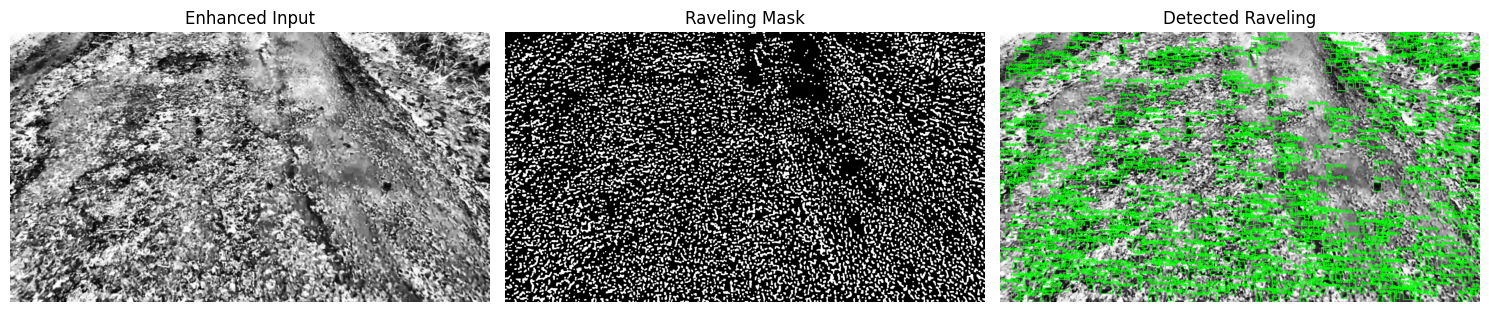

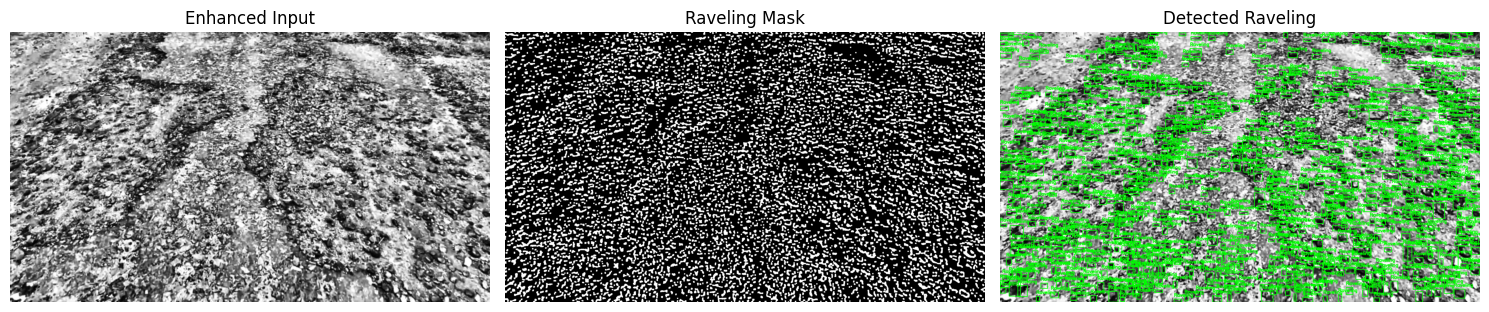

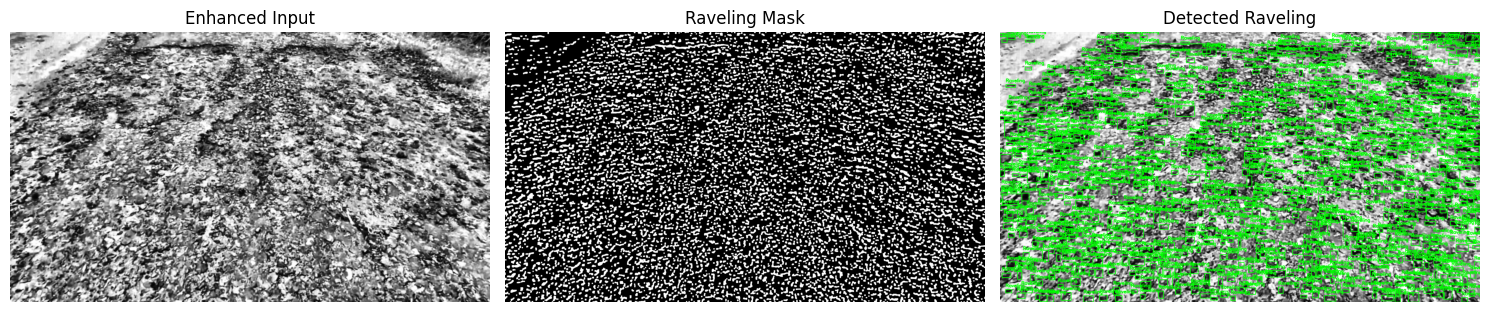

Raveling detection completed successfully!


In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Folder structure
input_folder = "../../frames/enhanced/4_FinalEnhanced/Raveling"
output_folder = "../../frames/segmented/Raveling"

os.makedirs(output_folder, exist_ok=True)

max_show = 3
count = 0


# Raveling detection function
def apply_enhancement(img):

    # Step 1: Smooth noise
    smoothed = cv2.blur(img, (3, 3))

    # Step 2: Logarithmic transformation
    img_float = smoothed.astype(np.float32)

    constant = 100 / np.log(
        1 + np.max(img_float)
    )

    log_img = constant * np.log(
        1 + img_float
    )

    log_img = np.array(
        log_img,
        dtype=np.uint8
    )

    # Step 3: Contrast Stretching
    low = np.min(log_img)
    high = np.max(log_img)

    if high <= low:
        return log_img

    stretched = cv2.convertScaleAbs(
        log_img,
        alpha=(255.0 / (high - low)),
        beta=-(low * 255.0 / (high - low))
    )

    return stretched

# Extract raveling damage
def extract_damage(enhanced_img):

    gaussian = cv2.GaussianBlur(
        enhanced_img,
        (5, 5),
        0
    )

    # Binarization
    binary = cv2.adaptiveThreshold(
        gaussian,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY_INV,
        15,
        3
    )

    # Noise removal
    struct_element = np.ones(
        (3, 3),
        np.uint8
    )

    refined_mask = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        struct_element,
        iterations=2
    )

    return refined_mask


# Detect raveling regions
def detect_raveling(image, mask):

    output = image.copy()

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for c in contours:

        if cv2.contourArea(c) > 150:

            x, y, w, h = cv2.boundingRect(c)

            cv2.rectangle(
                output,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            cv2.putText(
                output,
                "Raveling",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    return output


# Main processing loop
for file in os.listdir(input_folder):

    if file.endswith((".jpg", ".png", ".jpeg")):

        path = os.path.join(input_folder, file)

        img = cv2.imread(path)

        if img is None:
            continue

        gray = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

        # Apply enhancement
        enhanced = apply_enhancement(gray)

        # Extract damage
        mask = extract_damage(enhanced)

        # Detect raveling
        result = detect_raveling(img, mask)

        # Save result
        cv2.imwrite(
            os.path.join(output_folder, file),
            result
        )

        # Visualization
        if count < max_show:

            plt.figure(figsize=(15,5))

            plt.subplot(1,3,1)
            plt.imshow(gray, cmap="gray")
            plt.title("Enhanced Input")
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.imshow(mask, cmap="gray")
            plt.title("Raveling Mask")
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
            plt.title("Detected Raveling")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            count += 1

print("Raveling detection completed successfully!")